# Naive Bayes classification of habitable-zone membership from NASA Exoplanet Archive data

This notebook is designed for **Google Colab** and shows how to build a **Gaussian Naive Bayes** classifier to predict whether a confirmed exoplanet falls into a **simple habitable-zone label**.

## Important scientific note

This notebook uses a **toy habitable-zone classification** for teaching machine learning. It is **not** a full physical habitability assessment.

The default label is defined from two archive quantities:

- stellar insolation `pl_insol`
- planetary radius `pl_rade`

We label a planet as:

- `1` = habitable-zone-like candidate if `0.25 <= pl_insol <= 1.75` and `pl_rade <= 1.8`
- `0` = otherwise

This is only a classroom proxy. Real habitability depends on many additional factors: atmosphere, stellar variability, chemistry, tidal effects, age, magnetic environment, observational uncertainty, and model assumptions.

## What students will learn

In this notebook, students will:

1. download confirmed exoplanet data from the NASA Exoplanet Archive,
2. define a toy habitable-zone target,
3. avoid label leakage by excluding the variables used to define the label,
4. train a **Gaussian Naive Bayes** classifier,
5. evaluate it with **Stratified K-Fold cross-validation**, and
6. inspect model behavior and limitations.


## 1. Install and import packages

In [ ]:
!pip -q install pandas numpy scikit-learn matplotlib requests

In [ ]:
import urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)


## 2. Download data from the NASA Exoplanet Archive

We use the `pscomppars` table and request a compact set of columns that are useful for this exercise.

In [ ]:
base_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = r"""
select
    pl_name,
    hostname,
    discoverymethod,
    pl_orbper,
    pl_orbsmax,
    pl_rade,
    pl_bmasse,
    pl_dens,
    pl_orbeccen,
    pl_eqt,
    pl_insol,
    st_teff,
    st_rad,
    st_mass,
    st_met,
    st_logg,
    sy_dist,
    sy_snum,
    sy_pnum
from pscomppars
"""

url = f"{base_url}?query={urllib.parse.quote(query)}&format=csv"
df = pd.read_csv(url)

print('Raw dataset shape:', df.shape)
df.head()

Raw dataset shape: (6147, 19)


,pl_name,hostname,discoverymethod,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
0,Kepler-1167 b,Kepler-1167,Transit,1.003934,0.01750,1.710000,3.570,3.92,0.0,1419.0,1039.697,4971.0,0.750,0.790,-0.05,4.600,820.905,1,1
1,Kepler-1740 b,Kepler-1740,Transit,8.172400,0.07790,3.323214,11.000,1.65,0.0,858.0,127.950,5705.0,0.905,0.943,-0.06,4.499,1061.770,1,1
2,Kepler-1581 b,Kepler-1581,Transit,6.283855,0.06865,0.800000,0.437,4.69,0.0,1108.0,470.862,6022.0,1.230,1.120,0.07,4.310,493.175,1,1
3,Kepler-644 b,Kepler-644,Transit,3.173917,0.04641,3.150000,10.100,1.78,0.0,1655.0,2381.770,6747.0,1.810,1.490,0.08,4.090,1318.050,1,1
4,Kepler-1752 b,Kepler-1752,Transit,56.358501,0.26980,4.540605,18.700,1.10,0.0,419.0,7.290,5446.0,0.821,0.824,-0.20,4.525,962.888,1,1


## 3. Basic inspection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6147 entries, 0 to 6146
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6147 non-null   object 
 1   hostname         6147 non-null   object 
 2   discoverymethod  6147 non-null   object 
 3   pl_orbper        5814 non-null   float64
 4   pl_orbsmax       5831 non-null   float64
 5   pl_rade          6097 non-null   float64
 6   pl_bmasse        6116 non-null   float64
 7   pl_dens          6009 non-null   float64
 8   pl_orbeccen      5211 non-null   float64
 9   pl_eqt           4585 non-null   float64
 10  pl_insol         4308 non-null   float64
 11  st_teff          5858 non-null   float64
 12  st_rad           5834 non-null   float64
 13  st_mass          6139 non-null   float64
 14  st_met           5595 non-null   float64
 15  st_logg          5830 non-null   float64
 16  sy_dist          6120 non-null   float64
 17  sy_snum       

In [ ]:
df.isna().mean().sort_values(ascending=False)

,0
pl_insol,0.299170
pl_eqt,0.254108
pl_orbeccen,0.152269
st_met,0.089800
pl_orbper,0.054173
st_logg,0.051570
pl_orbsmax,0.051407
st_rad,0.050919
st_teff,0.047015
pl_dens,0.022450


## 4. Define the habitable-zone-like target

We first require the quantities needed to define the label.

### Toy label definition

A planet is labeled `hz_toy = 1` if:

- `pl_insol` is between 0.25 and 1.75 Earth insolation units,
- `pl_rade <= 1.8` Earth radii.

Otherwise, `hz_toy = 0`.

This gives a compact binary classification target suitable for class exercises.

In [ ]:
df_hz = df.dropna(subset=['pl_insol', 'pl_rade']).copy()
df_hz['hz_toy'] = ((df_hz['pl_insol'].between(0.25, 1.75)) & (df_hz['pl_rade'] <= 1.8)).astype(int)

print('Dataset after requiring label-defining columns:', df_hz.shape)
print(df_hz['hz_toy'].value_counts())
print(df_hz['hz_toy'].value_counts(normalize=True))

Dataset after requiring label-defining columns: (4302, 20)
hz_toy
0    4260
1      42
Name: count, dtype: int64
hz_toy
0    0.990237
1    0.009763
Name: proportion, dtype: float64


## 5. Quick visualization of the toy habitable-zone rule

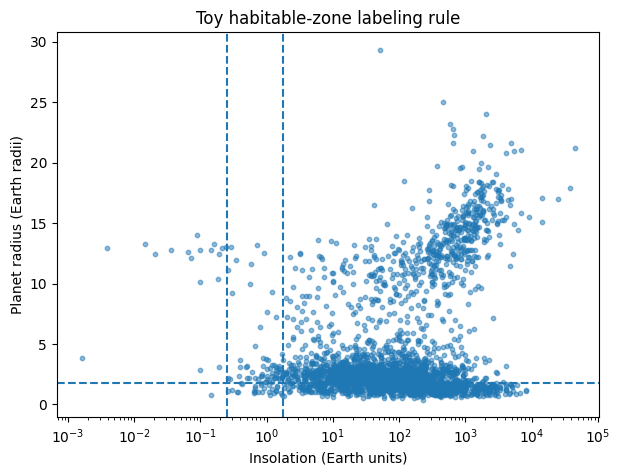

In [ ]:
plt.figure(figsize=(7, 5))
subset = df_hz.sample(min(len(df_hz), 3000), random_state=42)
plt.scatter(subset['pl_insol'], subset['pl_rade'], s=10, alpha=0.5)
plt.axvline(0.25, linestyle='--')
plt.axvline(1.75, linestyle='--')
plt.axhline(1.8, linestyle='--')
plt.xscale('log')
plt.xlabel('Insolation (Earth units)')
plt.ylabel('Planet radius (Earth radii)')
plt.title('Toy habitable-zone labeling rule')
plt.show()

## 6. Choose predictor features carefully

To avoid **label leakage**, we do **not** use `pl_insol` or `pl_rade` as predictors, because they were used to define the target itself.

Instead, we predict the label using orbital and stellar/system properties.

In [ ]:
feature_cols = [
    'pl_orbper',
    'pl_orbsmax',
    'pl_bmasse',
    'pl_dens',
    'pl_orbeccen',
    'pl_eqt',
    'st_teff',
    'st_rad',
    'st_mass',
    'st_met',
    'st_logg',
    'sy_dist',
    'sy_snum',
    'sy_pnum',
]

X = df_hz[feature_cols].copy()
y = df_hz['hz_toy'].copy()

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (4302, 14)
Target shape: (4302,)


## 7. Optional: log-transform skewed features

Some astrophysical quantities are very skewed. A log transform can make Gaussian Naive Bayes behave more sensibly.

We create a transformed copy for selected positive-valued features.

In [ ]:
X_model = X.copy()

log_cols = ['pl_orbper', 'pl_orbsmax', 'pl_bmasse', 'pl_dens', 'pl_eqt', 'sy_dist']

for col in log_cols:
    X_model[col] = np.where(X_model[col] > 0, np.log10(X_model[col]), np.nan)

X_model.head()

,pl_orbper,pl_orbsmax,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
0,0.001705,-1.756962,0.552668,0.593286,0.0,3.151982,4971.0,0.750,0.790,-0.05,4.600,2.914293,1,1
1,0.912350,-1.108463,1.041393,0.217484,0.0,2.933487,5705.0,0.905,0.943,-0.06,4.499,3.026030,1,1
2,0.798226,-1.163359,-0.359519,0.671173,0.0,3.044540,6022.0,1.230,1.120,0.07,4.310,2.693001,1,1
3,0.501596,-1.333388,1.004321,0.250420,0.0,3.218798,6747.0,1.810,1.490,0.08,4.090,3.119932,1,1
4,1.750959,-0.568958,1.271842,0.041393,0.0,2.622214,5446.0,0.821,0.824,-0.20,4.525,2.983576,1,1


## 8. Build the Gaussian Naive Bayes pipeline

In [ ]:
nb_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', GaussianNB()),
])

nb_model

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf', GaussianNB())])

## 9. Stratified K-fold cross-validation

We use `StratifiedKFold` so that each fold preserves the class balance as much as possible.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## 10. Cross-validated metrics

We compute accuracy, precision, recall, F1, and ROC AUC.

Because the habitable-zone-like class may be imbalanced, you should pay attention especially to recall, precision, and ROC AUC.

In [ ]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

cv_results = cross_validate(
    estimator=nb_model,
    X=X_model,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    metric: cv_results[f'test_{metric}']
    for metric in scoring.keys()
})

cv_summary

,accuracy,precision,recall,f1,roc_auc
0,0.945412,0.160714,1.000,0.276923,0.985263
1,0.939605,0.147541,1.000,0.257143,0.994392
2,0.951163,0.130435,0.750,0.222222,0.964789
3,0.950000,0.127660,0.750,0.218182,0.923415
4,0.956977,0.128205,0.625,0.212766,0.966843


In [ ]:
print('Cross-validation summary statistics:')
display(cv_summary.describe().T[['mean', 'std', 'min', 'max']])

Cross-validation summary statistics:


,mean,std,min,max
accuracy,0.948631,0.006515,0.939605,0.956977
precision,0.138911,0.014688,0.127660,0.160714
recall,0.825000,0.167705,0.625000,1.000000
f1,0.237447,0.028100,0.212766,0.276923
roc_auc,0.966941,0.027333,0.923415,0.994392


## 11. Plot fold-to-fold variation

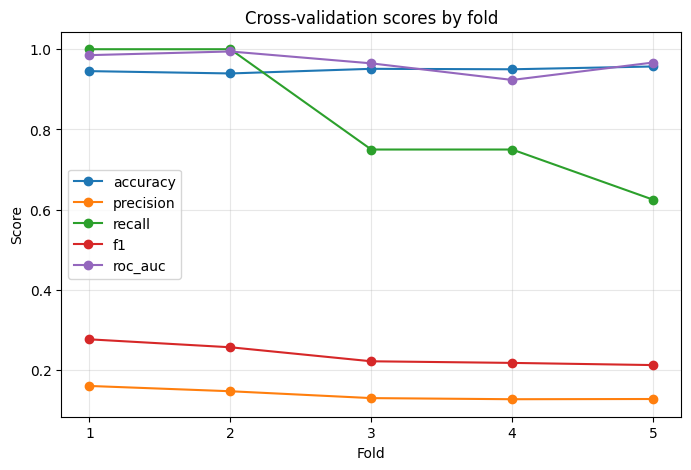

In [ ]:
plt.figure(figsize=(8, 5))
for col in cv_summary.columns:
    plt.plot(range(1, len(cv_summary) + 1), cv_summary[col], marker='o', label=col)

plt.xticks(range(1, len(cv_summary) + 1))
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Cross-validation scores by fold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Out-of-fold predictions for the full dataset

These are cross-validated predictions, so each object is predicted by a model that was not trained on it.

In [ ]:
y_pred_cv = cross_val_predict(nb_model, X_model, y, cv=cv, method='predict', n_jobs=-1)
y_proba_cv = cross_val_predict(nb_model, X_model, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

print(classification_report(y, y_pred_cv, digits=4))
print('Cross-validated ROC AUC:', roc_auc_score(y, y_proba_cv))

              precision    recall  f1-score   support

           0     0.9983    0.9498    0.9734      4260
           1     0.1406    0.8333    0.2405        42

    accuracy                         0.9486      4302
   macro avg     0.5694    0.8915    0.6070      4302
weighted avg     0.9899    0.9486    0.9663      4302

Cross-validated ROC AUC: 0.9654258886653253


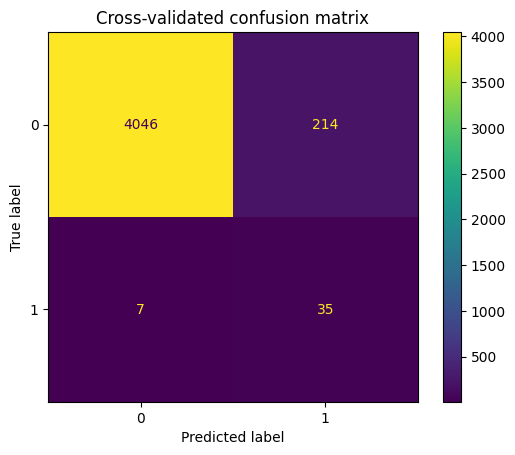

In [ ]:
cm = confusion_matrix(y, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Cross-validated confusion matrix')
plt.show()

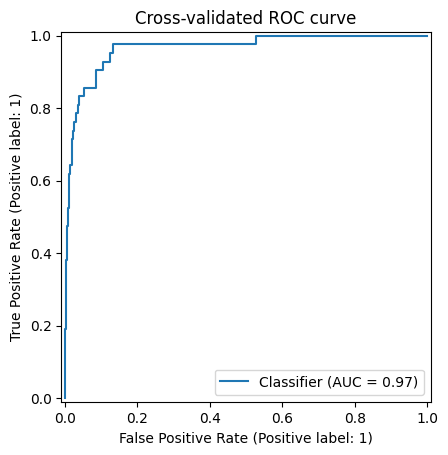

In [ ]:
RocCurveDisplay.from_predictions(y, y_proba_cv)
plt.title('Cross-validated ROC curve')
plt.show()

## 13. Compare with a single train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

nb_model.fit(X_train, y_train)
y_pred_test = nb_model.predict(X_test)
y_proba_test = nb_model.predict_proba(X_test)[:, 1]

single_split_results = {
    'accuracy': accuracy_score(y_test, y_pred_test),
    'precision': precision_score(y_test, y_pred_test),
    'recall': recall_score(y_test, y_pred_test),
    'f1': f1_score(y_test, y_pred_test),
    'roc_auc': roc_auc_score(y_test, y_proba_test),
}

pd.Series(single_split_results, name='single_split')

,single_split
accuracy,0.934015
precision,0.125000
recall,0.909091
f1,0.219780
roc_auc,0.975416


In [ ]:
comparison = pd.DataFrame({
    'cv_mean': cv_summary.mean(),
    'cv_std': cv_summary.std(),
    'single_split': pd.Series(single_split_results),
})

comparison

,cv_mean,cv_std,single_split
accuracy,0.948631,0.006515,0.934015
precision,0.138911,0.014688,0.125000
recall,0.825000,0.167705,0.909091
f1,0.237447,0.028100,0.219780
roc_auc,0.966941,0.027333,0.975416


## 14. Inspect Gaussian Naive Bayes parameters

For teaching, it is valuable to inspect the means and variances learned for each feature in each class.

In [ ]:
gnb = nb_model.named_steps['clf']

means = pd.DataFrame(gnb.theta_, columns=feature_cols, index=['class_0_not_hz', 'class_1_hz'])
variances = pd.DataFrame(gnb.var_, columns=feature_cols, index=['class_0_not_hz', 'class_1_hz'])

print('Learned class priors:')
print(gnb.class_prior_)
print()
print('Class-conditional means:')
display(means)
print('Class-conditional variances:')
display(variances)

Learned class priors:
[0.99039058 0.00960942]

Class-conditional means:


,pl_orbper,pl_orbsmax,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
class_0_not_hz,0.977005,-1.072800,1.070542,0.367244,0.036878,2.911354,5396.880382,1.018163,0.938913,0.018999,4.446476,2.586231,1.078560,1.78529
class_1_hz,1.406525,-0.972718,0.370533,0.690343,0.041859,2.460215,3478.774194,0.346894,0.340916,-0.072484,4.948037,1.441336,1.096774,3.00000


Class-conditional variances:


,pl_orbper,pl_orbsmax,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
class_0_not_hz,0.314144,0.143359,0.692832,0.200119,0.011423,0.047171,651359.799448,0.197841,0.072282,0.028816,0.057438,0.248575,0.088724,1.319217
class_1_hz,0.253262,0.194582,0.199682,0.022156,0.006068,0.035650,592178.369052,0.057034,0.065688,0.023792,0.057494,0.590114,0.152611,4.000686


## 15. Make a table of predictions

This is useful for students who want to inspect individual planets.

In [ ]:
results_table = df_hz[['pl_name', 'hostname', 'pl_insol', 'pl_rade'] + feature_cols].copy()
results_table['hz_toy_true'] = y.values
results_table['hz_toy_pred_cv'] = y_pred_cv
results_table['hz_toy_prob_cv'] = y_proba_cv

results_table.head(20)

,pl_name,hostname,pl_insol,pl_rade,pl_orbper,pl_orbsmax,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,...,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum,hz_toy_true,hz_toy_pred_cv,hz_toy_prob_cv
0,Kepler-1167 b,Kepler-1167,1039.697,1.710000,1.003934,0.01750,3.570,3.920,0.00,1419.0,...,0.750,0.790,-0.0500,4.600,820.905,1,1,0,0,1.215170e-10
1,Kepler-1740 b,Kepler-1740,127.950,3.323214,8.172400,0.07790,11.000,1.650,0.00,858.0,...,0.905,0.943,-0.0600,4.499,1061.770,1,1,0,0,9.238739e-14
2,Kepler-1581 b,Kepler-1581,470.862,0.800000,6.283855,0.06865,0.437,4.690,0.00,1108.0,...,1.230,1.120,0.0700,4.310,493.175,1,1,0,0,2.052133e-15
3,Kepler-644 b,Kepler-644,2381.770,3.150000,3.173917,0.04641,10.100,1.780,0.00,1655.0,...,1.810,1.490,0.0800,4.090,1318.050,1,1,0,0,5.079035e-29
4,Kepler-1752 b,Kepler-1752,7.290,4.540605,56.358501,0.26980,18.700,1.100,0.00,419.0,...,0.821,0.824,-0.2000,4.525,962.888,1,1,0,0,5.089410e-13
5,Kepler-280 c,Kepler-280,279.085,2.010000,4.807091,0.05600,4.700,3.180,0.00,1088.0,...,0.886,0.962,0.1213,4.537,780.361,1,2,0,0,1.556753e-11
6,Kepler-1208 b,Kepler-1208,37.664,2.320000,11.085076,0.09010,5.990,2.640,0.00,665.0,...,0.760,0.800,-0.0300,4.590,825.176,1,1,0,0,4.879975e-07
7,Kepler-263 c,Kepler-263,5.994,2.470000,47.332773,0.24200,6.660,2.430,0.00,386.0,...,0.785,0.793,-0.0314,4.576,754.747,1,2,0,0,4.975001e-07
8,Kepler-1101 b,Kepler-1101,3.577,2.470000,81.315106,0.34830,6.660,2.430,0.00,393.0,...,0.910,0.940,-0.0400,4.500,742.473,1,1,0,0,4.370742e-09
10,K2-19 b,K2-19,87.000,7.000000,7.922200,0.07400,32.400,0.520,0.20,779.0,...,0.820,0.880,0.0600,4.510,289.827,1,3,0,0,1.920736e-20


## 16. Save outputs

In [ ]:
results_table.to_csv('exoplanet_hz_nb_predictions.csv', index=False)
print('Saved exoplanet_hz_nb_predictions.csv')

## 17. Suggested student discussion

Students should discuss the following issues:

1. Why is this only a toy habitable-zone definition?
2. Why must `pl_insol` and `pl_rade` be excluded from the predictors?
3. Which metrics are most informative when the positive class is rare?
4. How realistic is the Gaussian assumption for these features?
5. How badly is the conditional independence assumption violated in planetary data?
6. Would logistic regression, tree methods, or calibrated probabilistic models perform better?

These questions are scientifically just as important as the code itself.